In [1]:
pip install TDCRPy==2.20.9

  Using cached tdcrpy-2.20.8-py3-none-any.whl.metadata (7.9 kB)
Using cached tdcrpy-2.20.8-py3-none-any.whl (23.5 MB)
  Attempting uninstall: TDCRPy
    Found existing installation: TDCRPy 2.20.7
    Uninstalling TDCRPy-2.20.7:
      Successfully uninstalled TDCRPy-2.20.7
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
Rad="H-3"                   # radionuclides
pmf_1="1"                   # relatives fractions of the radionulides
kB =0.7e-5                  # Birks constant in cm keV-1
V = 15                      # volume of scintillator in mL
ne = 10000                   # number of discretization steps for the numerical computation of the quenching function

Spectrum information

In [4]:
print(td.TDCR_model_lib.readBetaShapeInfo(Rad,'beta-','tot'))

-Beta Spectrum from BetaShape 2.4 (05/2024), DDEP 2006
 evaluation and Q-value from AME2020-


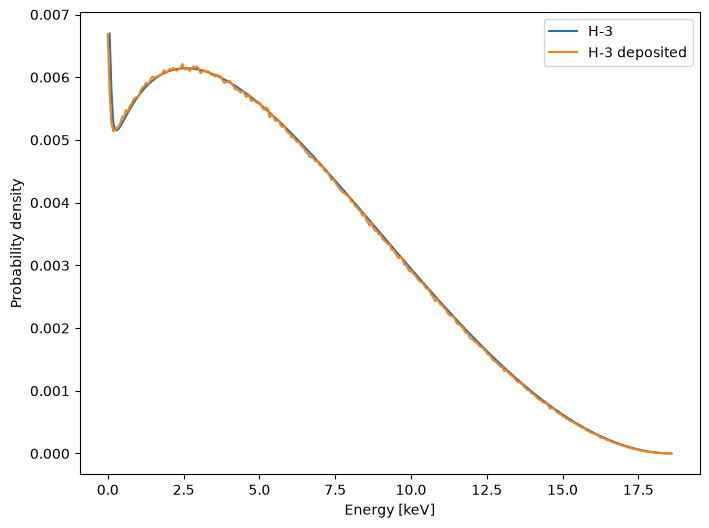

In [5]:
dataSpectrum =td.TDCR_model_lib.readBetaShape(Rad,'beta-','tot')
dataSpectrumDeposited = td.TDCR_model_lib.readBetaSpectra(Rad)

plt.figure(figsize=(8,6))
plt.plot(dataSpectrum[0][1:],dataSpectrum[1],label=Rad)
plt.plot(dataSpectrumDeposited[0],dataSpectrumDeposited[1],label=Rad+' deposited')
plt.xlabel('Energy [keV]')
plt.ylabel('Probability density')
plt.legend()
plt.show()

## Analytical model

In [6]:
TD = 0.7747     # TDCR parameter
# TAB = 0.992232838598821    # TDCR parameter T/AB
# TBC = 0.992343419459002    # TDCR parameter T/BC
# TAC = 0.99275350064608     # TDCR parameter T/AC
minL = 0.1                 # minimum light yield (keV-1)
maxL = 50                  # maximum light yield (keV-1)

result_analitical = td.TDCRPy.effA(TD, Rad, pmf_1, kB, V, Lbounds=[minL, maxL])

## Stochastic model

In [7]:
# modification of advanced parameters
lsCocktail = "Ultima Gold" # type of LS cocktail
frac_aq = 0.05             # aqueous fraction
solvant = "HCl"            # type of solvant
solvant_conc = 0.1         # concentration of solvant mol/L
t_W = 50                   # coincidence resolving time ns
t_EXT = 100                # extended dead time µs
quantum_effA = 0.25        # quantum efficiency of PMT A
quantum_effB = 0.25        # quantum efficiency of PMT B
quantum_effC = 0.25        # quantum efficiency of PMT C
N=10000                    # number of Monte-Carlo trials

td.TDCR_model_lib.modifyTau(int(t_W))
td.TDCR_model_lib.modifyDeadTime(int(t_EXT))
td.TDCR_model_lib.modifyEffQ(str(quantum_effA)+","+str(quantum_effB )+","+str(quantum_effC))
td.TDCR_model_lib.modifySolvantType(solvant)
td.TDCR_model_lib.modifySolvantConc(solvant_conc)
td.TDCR_model_lib.modifyLScocktail(lsCocktail, frac_aq, solvantType=solvant, solvantConc=solvant_conc)

micellCorr = False          # inactivate Micelle correction
td.TDCR_model_lib.modifyMicCorr(micellCorr)
result_stochastic = td.TDCRPy.eff(TD, Rad, pmf_1, kB, V, N, Lbounds=(minL, maxL))

micellCorr = True          # activate Micelle correction
diam_micelle = 4           # micelle diameter in nm
sigma_micelle = 1          # standard deviation of the micelle diameter in nm
td.TDCR_model_lib.modifyMicCorr(micellCorr)
td.TDCR_model_lib.modifyDiam_micelle(diam_micelle)
td.TDCR_model_lib.modifySigma_micelle(sigma_micelle)
result_stochastic_micelle = td.TDCRPy.eff(TD, Rad, pmf_1, kB, V, N, Lbounds=(minL, maxL))

QUENCHING NUMERICAL CALCULATION
	Number of bins to discretize
	the linear energy space
	for quenching calculation:
	for electrons = 1000 bins
	the stopping power model at low energy = tan_xia
	for alphas = 1000 bins
	Chou quenching parameter 0.0 cm2/MeV2

PROPERTIES OF THE SCINTILLATOR
	Liquid scintillation cocktail = Ultima Gold
	acqueous fraction = 0.05 (Type: HCl, 0.1 mol/L)
	Density = 0.9808942233452657 g/cm3
	Z = 3.2559, A = 5.9487
	Atomic fraction: H=0.5747, C=0.3711, N=0.0009, O=0.0500
	                 P=0.0024, S=0.0004, Na=0.0004, Cl=0.0000
	Micelle correction not activated

OPTICAL PROPERTIES
	Quantum efficiency of PMT A = 0.250
	Quantum efficiency of PMT B = 0.250
	Quantum efficiency of PMT C = 0.250

PROPERTIES OF THE COUNTER
	Coincidence resolving time = 50 ns
	Extended dead time = 100.0 µs
	Measurement time = 20.0 min


In [8]:
print(f"\nResults using a global parameter")
print(f"Global free parameter: {result_analitical[0]:.2f} keV-1 (photoelectrons/keV)")
print(f"Efficiency of single events: {result_analitical[2]:.3f}")
print(f"Efficiency of double coincidence events: {result_analitical[3]:.3f}")
print(f"Efficiency of triple coincidence events: {result_analitical[4]:.3f}\n")

print(f"\nResults using a stochastic approach without Micelle correction")
print(f"global free parameter (light yield) = {round(result_stochastic[0],4)} keV-1")
print(f"global free parameter (PMT A) = {round(result_stochastic[1][0],4)} keV-1")
print(f"global free parameter (PMT B) = {round(result_stochastic[1][1],4)} keV-1")
print(f"global free parameter (PMT C) = {round(result_stochastic[1][2],4)} keV-1")
print(f"efficiency S = {round(result_stochastic[2],4)} +/- {round(result_stochastic[3],4)}")
print(f"efficiency D = {round(result_stochastic[4],4)} +/- {round(result_stochastic[5],4)}")
print(f"efficiency T = {round(result_stochastic[6],4)} +/- {round(result_stochastic[7],4)}")
print(f"efficiency AB = {round(result_stochastic[8],4)} +/- {round(result_stochastic[9],4)}")
print(f"efficiency BC = {round(result_stochastic[10],4)} +/- {round(result_stochastic[11],4)}")
print(f"efficiency AC = {round(result_stochastic[12],4)} +/- {round(result_stochastic[13],4)}")

print(f"\nResults using a stochastic approach with Micelle correction")
print(f"global free parameter (light yield) = {round(result_stochastic_micelle[0],4)} keV-1")
print(f"global free parameter (PMT A) = {round(result_stochastic_micelle[1][0],4)} keV-1")
print(f"global free parameter (PMT B) = {round(result_stochastic_micelle[1][1],4)} keV-1")
print(f"global free parameter (PMT C) = {round(result_stochastic_micelle[1][2],4)} keV-1")
print(f"efficiency S = {round(result_stochastic_micelle[2],4)} +/- {round(result_stochastic_micelle[3],4)}")
print(f"efficiency D = {round(result_stochastic_micelle[4],4)} +/- {round(result_stochastic_micelle[5],4)}")
print(f"efficiency T = {round(result_stochastic_micelle[6],4)} +/- {round(result_stochastic_micelle[7],4)}")
print(f"efficiency AB = {round(result_stochastic_micelle[8],4)} +/- {round(result_stochastic_micelle[9],4)}")
print(f"efficiency BC = {round(result_stochastic_micelle[10],4)} +/- {round(result_stochastic_micelle[11],4)}")
print(f"efficiency AC = {round(result_stochastic_micelle[12],4)} +/- {round(result_stochastic_micelle[13],4)}") 


Results using a global parameter
Global free parameter: 21.81 keV-1 (photoelectrons/keV)
Efficiency of single events: 0.777
Efficiency of double coincidence events: 0.800
Efficiency of triple coincidence events: 0.620


Results using a stochastic approach without Micelle correction
global free parameter (light yield) = 21.9771 keV-1
global free parameter (PMT A) = 21.9771 keV-1
global free parameter (PMT B) = 21.9771 keV-1
global free parameter (PMT C) = 21.9771 keV-1
efficiency S = 0.9131 +/- 0.002
efficiency D = 0.8036 +/- 0.003
efficiency T = 0.6226 +/- 0.0036
efficiency AB = 0.6829 +/- 0.0034
efficiency BC = 0.6829 +/- 0.0034
efficiency AC = 0.6829 +/- 0.0034

Results using a stochastic approach with Micelle correction
global free parameter (light yield) = 24.2087 keV-1
global free parameter (PMT A) = 24.2087 keV-1
global free parameter (PMT B) = 24.2087 keV-1
global free parameter (PMT C) = 24.2087 keV-1
efficiency S = 0.8962 +/- 0.0024
efficiency D = 0.7924 +/- 0.0032
efficiency

## Comparison

In [9]:
print('\nComparison of the results with and without Micelle correction\n')
print(f"Deviation of the double coincidence efficiency: {round(result_stochastic_micelle[4]-result_stochastic[4],4)} +/- {round(result_stochastic_micelle[5]-result_stochastic[5],4)}")
print(f"Deviation of the triple coincidence efficiency: {round(result_stochastic_micelle[6]-result_stochastic[6],4)} +/- {round(result_stochastic_micelle[7]-result_stochastic[7],4)}")
print(f"Deviation of the global free parameter (light yield): {round(result_stochastic_micelle[0]-result_stochastic[0],4)} keV-1")

print("\nComparison with the analitical approach\n")
print(f"Deviation of the double coincidence efficiency: {round(result_stochastic[4]-result_analitical[3],4)} +/- {round(result_stochastic[5],4)}")
print(f"Deviation of the triple coincidence efficiency: {round(result_stochastic[6]-result_analitical[4],4)} +/- {round(result_stochastic[7],4)}")
print(f"Deviation of the global free parameter (light yield): {round(result_stochastic[0]-result_analitical[0]/quantum_effA,4)} keV-1")


Comparison of the results with and without Micelle correction

Deviation of the double coincidence efficiency: -0.0112 +/- 0.0001
Deviation of the triple coincidence efficiency: -0.0087 +/- 0.0
Deviation of the global free parameter (light yield): 2.2317 keV-1

Comparison with the analitical approach

Deviation of the double coincidence efficiency: 0.0033 +/- 0.003
Deviation of the triple coincidence efficiency: 0.0026 +/- 0.0036
Deviation of the global free parameter (light yield): -65.2639 keV-1
